# Анализ лояльности пользователей Яндекс Афиши

В данном проекте будет изучено влияние различных факторов на лояльность клиентов. Исследование основано на данных о пользователях Яндекс Афиши за период с 1 июня по 31 октября 2024 года. 
Датасет уже подготовлен с помощью запросов SQL, соответственно необходимо выгрузить его в датафрейм для дальнейшего исследования. 

После стандартного этапа предобработки необходимо создать датафрейм с различными признаками пользователей для дальнейшего анализа. В данном проекте будет изучена доля лояльных пользователей по следующим сегментам: регион первого заказа, день недели первого заказа, тип первого посещённого мероприятия, сервис, с помощью которого был сделан первый заказ, устройство, с которого сделан первый заказ, среднее количество билетов в заказе, средние промежутки между заказами. Также необходимо исследовать корреляцию между этими признаками и лояльностью пользователей. 

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
#Устанавливаем библиотеки, необходимые для работы с данными, в том числе для выгрузки необходимой части датасета через запрос sql:
!pip install -q sqlalchemy==2.0.52

In [2]:
!pip install -q psycopg2

In [3]:
!pip install -q phik

In [4]:
!pip install -q pandas==3.0.5

ERROR: Could not find a version that satisfies the requirement pandas==3.0.5 (from versions: 0.1, 0.2, 0.3.0, 0.4.0, 0.4.1, 0.4.2, 0.4.3, 0.5.0, 0.6.0, 0.6.1, 0.7.0, 0.7.1, 0.7.2, 0.7.3, 0.8.0, 0.8.1, 0.9.0, 0.9.1, 0.10.0, 0.10.1, 0.11.0, 0.12.0, 0.13.0, 0.13.1, 0.14.0, 0.14.1, 0.15.0, 0.15.1, 0.15.2, 0.16.0, 0.16.1, 0.16.2, 0.17.0, 0.17.1, 0.18.0, 0.18.1, 0.19.0, 0.19.1, 0.19.2, 0.20.0, 0.20.1, 0.20.2, 0.20.3, 0.21.0, 0.21.1, 0.22.0, 0.23.0, 0.23.1, 0.23.2, 0.23.3, 0.23.4, 0.24.0, 0.24.1, 0.24.2, 0.25.0, 0.25.1, 0.25.2, 0.25.3, 1.0.0, 1.0.1, 1.0.2, 1.0.3, 1.0.4, 1.0.5, 1.1.0, 1.1.1, 1.1.2, 1.1.3, 1.1.4, 1.1.5, 1.2.0, 1.2.1, 1.2.2, 1.2.3, 1.2.4, 1.2.5, 1.3.0, 1.3.1, 1.3.2, 1.3.3, 1.3.4, 1.3.5, 1.4.0, 1.4.1, 1.4.2, 1.4.3, 1.4.4, 1.5.0, 1.5.1, 1.5.2, 1.5.3, 2.0.0, 2.0.1, 2.0.2, 2.0.3, 2.1.0, 2.1.1, 2.1.2, 2.1.3, 2.1.4, 2.2.0, 2.2.1, 2.2.2, 2.2.3, 2.3.0, 2.3.1, 2.3.2, 2.3.3)
ERROR: No matching distribution found for pandas==3.0.5


In [5]:
import pandas as pd
import numpy as np
import sqlalchemy
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
from phik import phik_matrix
from IPython.display import HTML
from statistics import mean
from datetime import timedelta


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\User\anaconda3\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\User\anaconda3\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "C:\Users\User\anaconda3\lib\site-packages\ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "C:\Users\User\anaconda3\lib\site-packages\traitlets\config\application.py", line 846, in launch_instance
    app.start()
  File "C:\Users\User\anaconda3\lib\site-packages\

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\User\anaconda3\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\User\anaconda3\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "C:\Users\User\anaconda3\lib\site-packages\ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "C:\Users\User\anaconda3\lib\site-packages\traitlets\config\application.py", line 846, in launch_instance
    app.start()
  File "C:\Users\User\anaconda3\lib\site-packages\

AttributeError: _ARRAY_API not found

In [6]:
!pip freeze > requirements.txt

In [7]:
#Ссылка для скачивания файла с зависимостями:
HTML('<a href="requirements.txt" download="requirements.txt">Скачать requirements.txt</a>')

In [8]:
sqlalchemy.__version__

'2.0.52'

In [9]:
pd.__version__

'2.3.3'

In [10]:
db_config = {'user': 'praktikum_student', # имя пользователя
             'pwd': 'Sdf4$2;d-d30pp', # пароль
             'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
             'port': 6432, # порт подключения
             'db': 'data-analyst-afisha' # название базы данных
             }

In [11]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

In [12]:
engine = create_engine(connection_string)

In [13]:
query = '''
SELECT p.user_id, 
       p.device_type_canonical, 
       p.order_id, 
       p.created_dt_msk AS order_dt, 
       p.created_ts_msk AS order_ts, 
       p.currency_code, 
       p.revenue, 
       p.tickets_count, 
       p.created_dt_msk::date - LAG(p.created_dt_msk::date) OVER(PARTITION BY p.user_id ORDER BY p.created_dt_msk) days_since_prev, 
       p.event_id, 
       e.event_name_code AS event_name, 
       e.event_type_main, 
       p.service_name, 
       r.region_name, 
       c.city_name
FROM afisha.purchases p
JOIN afisha.events e ON p.event_id = e.event_id
JOIN afisha.city c ON e.city_id = c.city_id
JOIN afisha.regions r ON c.region_id = r.region_id
WHERE p.device_type_canonical IN ('desktop', 'mobile') AND e.event_type_main NOT IN ('фильм')
ORDER BY p.user_id
'''

In [14]:
df = pd.read_sql_query(query, con=engine)

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [15]:
#Изучим общую информацию о датафрейме:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

Отлично! Ни в одном столбце нет пропусков, за исключением столбца `days_since_prev`. Но они должны иметь место в случае, если пользователь совершил лишь одну покупку.

В датафрейме 290611 строк. Большинство столбцов имеют корректный формат данных. Стоит проверить возможность уменьшения разрядности столбца `tickets_count` и преобразовать столбец `days_since_prev` в целочисленный формат.

In [16]:
#Изучим значения столбца 'tickets_count':
df['tickets_count'].unique()

array([ 4,  2,  3,  1,  5,  6, 10,  9,  7, 15, 13, 11,  8, 14, 12, 47, 27,
       17, 19, 57, 30, 37])

In [17]:
df['tickets_count'] = pd.to_numeric(df['tickets_count'], downcast='integer')

In [18]:
#Теперь изменим формат столбца 'days_since_prev':
df['days_since_prev'] = df['days_since_prev'].astype('Int64')

#Проверим, что вышло:
df['days_since_prev'].head()

0    <NA>
1    <NA>
2      75
3    <NA>
4      83
Name: days_since_prev, dtype: Int64

Для удобства работы данные столбца `days_since_prev` были преобразованы в целочисленный формат, а разрядность столбца `tickets_count` уменьшена.

In [19]:
#Проверим категориальные столбцы на дубликаты:

df['device_type_canonical'].unique()

array(['mobile', 'desktop'], dtype=object)

In [20]:
df['currency_code'].unique()

array(['rub', 'kzt'], dtype=object)

In [21]:
df['event_type_main'].unique()

array(['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт',
       'ёлки'], dtype=object)

In [22]:
df['service_name'].unique()

array(['Край билетов', 'Мой билет', 'За билетом!', 'Лови билет!',
       'Билеты без проблем', 'Облачко', 'Лучшие билеты', 'Прачечная',
       'Быстробилет', 'Дом культуры', 'Весь в билетах', 'Билеты в руки',
       'Тебе билет!', 'Show_ticket', 'Городской дом культуры', 'Яблоко',
       'Билет по телефону', 'Выступления.ру', 'Росбилет',
       'Шоу начинается!', 'Мир касс', 'Восьмёрка', 'Телебилет',
       'Crazy ticket!', 'Реестр', 'Быстрый кассир', 'КарандашРУ',
       'Радио ticket', 'Дырокол', 'Вперёд!', 'Кино билет', 'Цвет и билет',
       'Зе Бест!', 'Тех билет', 'Лимоны', 'Билеты в интернете'],
      dtype=object)

Итак, дубликатов в категориальных столбцах не наблюдается. 

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [23]:
#Выгрузим датасет с курсом тенге к рублю на 2024 год для дальнейшей унификации данных о выручке:
df_rub_kzt = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

In [24]:
#Изучим данные нового датафрейма:
df_rub_kzt.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [25]:
#Переименуем столбец 'data' для более удобного объединения датафреймов:
df_rub_kzt = df_rub_kzt.rename(columns={'data' : 'order_dt'})

In [26]:
#Изучим информацию о форматах, в которых хранятся данные нового датафрейма:
df_rub_kzt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   order_dt  357 non-null    object 
 1   nominal   357 non-null    int64  
 2   curs      357 non-null    float64
 3   cdx       357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [27]:
df_rub_kzt['order_dt'] = pd.to_datetime(df_rub_kzt['order_dt'], format='%Y-%m-%d')

In [28]:
df_rub_kzt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   order_dt  357 non-null    datetime64[ns]
 1   nominal   357 non-null    int64         
 2   curs      357 non-null    float64       
 3   cdx       357 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 11.3+ KB


In [29]:
#Теперь объединим датафреймы:
df_merged = pd.merge(df, df_rub_kzt, on='order_dt')

In [30]:
#Изучим информацию о получившемся датафрейме:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int8          
 8   days_since_prev        268678 non-null  Int64         
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

Датафреймы объединены корректно. Теперь необходимо преобразовать цены в тенге в соответствующие в рублях. Далее для удобства преобразования данных о ценах в тенге в цены в рублях, необходимо поделить значения в столбцах `nominal` и `curs` на 100.

In [31]:
df_merged['nominal'] = df_merged['nominal']/100
df_merged['curs'] = df_merged['curs']/100

In [32]:
df_merged[['nominal', 'curs']].head()

,nominal,curs
0,1.0,0.186972
1,1.0,0.183419
2,1.0,0.196475
3,1.0,0.185010
4,1.0,0.196648


In [33]:
#Теперь преобразим цены в тенге в соответствующие рублёвые и создадим новый столбец:

df_merged['revenue_rub'] = np.where(df_merged['currency_code'] == 'kzt',
                               df_merged['revenue'] * df_merged['curs'],
                               df_merged['revenue'])

Для более удобного анализа данных смешанные данные в столбце `revenue`, содержащие информацию о выручке и в рублях, и в тенге, были преобразованы в данные, выраженные только в рублёвом эквиваленте. При преобразовании данных использовалась информация о курсе тенге к рублю в 2024 году.

---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [34]:
#Изучим столбцы с номинальными данными:

for column in ['device_type_canonical', 'currency_code', 'event_type_main', 'service_name', 'region_name', 'city_name']:
    print(f"\nColumn: {column}")
    print("Unique values:", df_merged[column].unique())
    print("Missing values count:", df_merged[column].isna().sum())
    print("Value counts:")
    print(df_merged[column].value_counts(dropna=False), "\n")


Column: device_type_canonical
Unique values: ['mobile' 'desktop']
Missing values count: 0
Value counts:
device_type_canonical
mobile     232490
desktop     58121
Name: count, dtype: int64 


Column: currency_code
Unique values: ['rub' 'kzt']
Missing values count: 0
Value counts:
currency_code
rub    285542
kzt      5069
Name: count, dtype: int64 


Column: event_type_main
Unique values: ['театр' 'выставки' 'другое' 'стендап' 'концерты' 'спорт' 'ёлки']
Missing values count: 0
Value counts:
event_type_main
концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки          1989
Name: count, dtype: int64 


Column: service_name
Unique values: ['Край билетов' 'Мой билет' 'За билетом!' 'Лови билет!'
 'Билеты без проблем' 'Облачко' 'Лучшие билеты' 'Прачечная' 'Быстробилет'
 'Дом культуры' 'Весь в билетах' 'Билеты в руки' 'Тебе билет!'
 'Show_ticket' 'Городской дом культуры' 'Яблоко' 'Билет по телефону'
 'Выступления.ру' 'Росбилет' 

Данные столбцы в нормализации не нуждаются. Теперь изучим разброс в столбцах с выручкой и количеством билетов.

In [35]:
df_merged['revenue_rub'].describe()

count    290611.000000
mean        555.571987
std         875.498172
min         -90.760000
25%         113.970000
50%         351.140000
75%         802.050000
max       81174.540000
Name: revenue_rub, dtype: float64

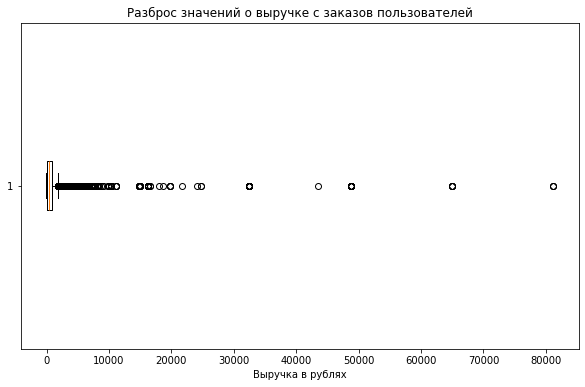

In [36]:
plt.figure(figsize=(10, 6))
plt.boxplot(df_merged['revenue_rub'], vert=False)
plt.title('Разброс значений о выручке с заказов пользователей')
plt.xlabel('Выручка в рублях')
plt.show()

В столбце присутствует аномальное отрицательное значение, а также выбросы. При 50-м процентиле в 351 рубль и среднем значении около 556 рублей максимальное значение составляет более 81000 рублей. Отфильтруем значения по 99-му процентилю, а также отбросим отрицательные значения.

In [37]:
percentile_99 = df_merged['revenue_rub'].quantile(0.99)
df_merged['revenue_rub'] = df_merged['revenue_rub'][df_merged['revenue_rub']<=percentile_99]
df_merged['revenue_rub'] = df_merged['revenue_rub'][df_merged['revenue_rub']>=0]

In [38]:
#Теперь изучим столбец 'tickets_count':

df_merged['tickets_count'].describe()

count    290611.000000
mean          2.754311
std           1.170620
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64

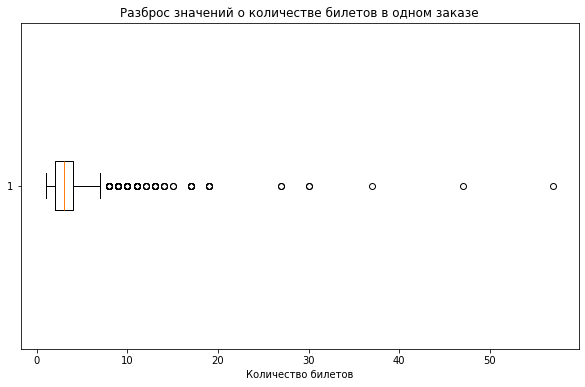

In [39]:
plt.figure(figsize=(10, 6))
plt.boxplot(df_merged['tickets_count'], vert=False)
plt.title('Разброс значений о количестве билетов в одном заказе')
plt.xlabel('Количество билетов')
plt.show()

В данном столбце тоже присутствуют выбросы, но их оставим как есть. Возможно, заказы на десятки билетов сделаны профсоюзными организациями или руководством компаний для сотрудников.

In [40]:
#Теперь изучим отфильтрованный датафрейм:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int8          
 8   days_since_prev        268678 non-null  Int64         
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

In [41]:
#Проверим идентификаторы заказов на предмет дубликатов:

df_merged['order_id'].duplicated().sum()

np.int64(0)

Теперь изучим данные на предмет повторяющихся заказов одних и тех же пользователей на одно и то же мероприятие, дабы избежать в дальнейшем задублировавшихся данных при анализе.

In [42]:
df_merged.groupby(['user_id', 'event_name'])['order_id'].count().sort_values(ascending=False)

user_id          event_name                          
3bfb9060ed61a76  0cf45604-0b36-4172-98e2-d1dd5c88bdf7    145
4226e240b0f7a38  f81d23fb-22fa-47c6-a156-b415321b693a    138
0beb8fc0c0a9ce1  9cc55c15-4375-4129-9979-3129688ba1b4    121
8d6c1ff89fac35f  c9eb1fa4-257b-4290-975a-7fe34b46d11b    114
7eb4fc207ecc10f  f840fd65-612b-448d-8483-e12d263a013d    114
                                                        ... 
001e7037d013f0f  0f8e05fc-56be-4bc7-b775-e3cd61ae6fe4      1
                 ba2dbc92-2c6e-43cb-ae5a-ee5e1c5e4a14      1
                 e252d33a-2394-44b8-b11d-f0709a6f0260      1
ffed3ff067d4f12  de81a256-b90d-4a54-823e-89e9093c6d58      1
fff13b79bd47d7c  3ccd92b9-5450-40a1-a7a8-5075cf90cc6a      1
Name: order_id, Length: 155680, dtype: int64

Вскрылась весьма существенная проблема: один пользователь явно не мог сделать более сотни заказов на одно и то же мероприятие. Будем исходить из более реалистичных цифр - что на один одно мероприятие приходится один заказ пользователя.

In [43]:
df_merged = df_merged.drop_duplicates(subset=['user_id', 'order_dt'], keep='first')
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 106559 entries, 0 to 290610
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                106559 non-null  object        
 1   device_type_canonical  106559 non-null  object        
 2   order_id               106559 non-null  int64         
 3   order_dt               106559 non-null  datetime64[ns]
 4   order_ts               106559 non-null  datetime64[ns]
 5   currency_code          106559 non-null  object        
 6   revenue                106559 non-null  float64       
 7   tickets_count          106559 non-null  int8          
 8   days_since_prev        84626 non-null   Int64         
 9   event_id               106559 non-null  int64         
 10  event_name             106559 non-null  object        
 11  event_type_main        106559 non-null  object        
 12  service_name           106559 non-null  object   

In [44]:
#Проведём повторную проверку о количестве заказов пользователей на одно мероприятие:
df_merged.groupby(['user_id', 'event_name'])['order_id'].count().sort_values(ascending=False)

user_id          event_name                          
15b05dc9441d9d1  1299fb86-3b14-4890-846e-d38e90555c3e    19
3bfb9060ed61a76  0cf45604-0b36-4172-98e2-d1dd5c88bdf7    16
9dc2c5813f1df81  603c97c6-b64f-4ec6-8de9-20b95c20b2b5    14
f6af1139a64d911  fc9cdc7f-f9be-48aa-93d9-053d46dfe72d    13
553ff264e9b07a5  64d0ed82-d761-4233-92f9-84bf7555d1fa    12
                                                         ..
fff32fc9ad0f9f6  9dbaefe5-56de-4b32-b991-7e9e4d04b702     1
fffcd3dde79eb2c  094241a6-aedc-47ad-bfa9-89c2a6cd9d07     1
                 3f8555f5-b0b9-4780-94c9-afed2ab7f864     1
                 58b0894b-d689-4385-b696-5de55ddfbaec     1
000898990054619  10d805d3-9809-4d8a-834e-225b7d03f95d     1
Name: order_id, Length: 98828, dtype: int64

Итак, после удаления неявных дубликатов в датафрейме осталось 155680 строк. Данная фильтрация позволит избежать нереалистичных значений о количестве заказов пользователей при анализе.

В результате предобработки в целочисленный формат был переведён столбец `days_since_prev`, а `tickets_count` оптимизирован. Кроме того, был создан столбец `revenue_rub`, содержащий в себе данные о выручке только в рублях, в отличие от столбца `revenue`, в котором помещены данные о выручке и в рублях, и в тенге. Также данные столбца `revenue_rub` были отфильтрованы по 99-му процентилю из-за наличия выбросов. Кроме того, удалены отрицательные значения. Количество строк в столбце `revenue_rub` сократилось на 3206. Также были удалены лишние данные о заказах, якобы сделанных пользователями на одно мероприятие множество раз.

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [45]:
#Для начала отсортируем данные по возрастанию даты заказа:
df_merged = df_merged.sort_values(by='order_dt')

In [46]:
#Теперь создадим столбцы с датами первого и последнего заказов, сгруппировав их по пользователям:

first_order_dates = df_merged.groupby('user_id')['order_dt'].min().reset_index()
first_order_dates.columns = ['user_id', 'first_order_dt']


last_order_dates = df_merged.groupby('user_id')['order_dt'].max().reset_index()
last_order_dates.columns = ['user_id', 'last_order_dt']
users_profiles = pd.merge(first_order_dates, last_order_dates, on='user_id')

In [47]:
users_profiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21933 entries, 0 to 21932
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_id         21933 non-null  object        
 1   first_order_dt  21933 non-null  datetime64[ns]
 2   last_order_dt   21933 non-null  datetime64[ns]
dtypes: datetime64[ns](2), object(1)
memory usage: 514.2+ KB


In [48]:
users_profiles = pd.merge(users_profiles, df_merged[['user_id', 'order_dt', 'order_ts', 'device_type_canonical']], left_on=['user_id', 'first_order_dt'], right_on=['user_id', 'order_dt'], how='left')

In [49]:
users_profiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21933 entries, 0 to 21932
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   user_id                21933 non-null  object        
 1   first_order_dt         21933 non-null  datetime64[ns]
 2   last_order_dt          21933 non-null  datetime64[ns]
 3   order_dt               21933 non-null  datetime64[ns]
 4   order_ts               21933 non-null  datetime64[ns]
 5   device_type_canonical  21933 non-null  object        
dtypes: datetime64[ns](4), object(2)
memory usage: 1.0+ MB


In [50]:
first_order_ts = df_merged.groupby('user_id')['order_ts'].min().reset_index()
first_order_ts.columns = ['user_id', 'order_ts']
users_profiles = pd.merge(users_profiles, first_order_ts, on=['user_id', 'order_ts'], how='inner')
users_profiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21933 entries, 0 to 21932
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   user_id                21933 non-null  object        
 1   first_order_dt         21933 non-null  datetime64[ns]
 2   last_order_dt          21933 non-null  datetime64[ns]
 3   order_dt               21933 non-null  datetime64[ns]
 4   order_ts               21933 non-null  datetime64[ns]
 5   device_type_canonical  21933 non-null  object        
dtypes: datetime64[ns](4), object(2)
memory usage: 1.0+ MB


In [51]:
users_profiles = users_profiles.rename({'device_type_canonical' : 'first_order_device'})

In [52]:
#Теперь добавим столбцы с данными о регионе первого заказа, билетного сервиса и жанра первого посещённого мероприятия по пользователям:

users_profiles = pd.merge(users_profiles, df_merged[['user_id', 'order_ts', 'region_name', 'service_name', 'event_type_main']], on=['user_id', 'order_ts'], how='inner')
users_profiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21933 entries, 0 to 21932
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   user_id                21933 non-null  object        
 1   first_order_dt         21933 non-null  datetime64[ns]
 2   last_order_dt          21933 non-null  datetime64[ns]
 3   order_dt               21933 non-null  datetime64[ns]
 4   order_ts               21933 non-null  datetime64[ns]
 5   device_type_canonical  21933 non-null  object        
 6   region_name            21933 non-null  object        
 7   service_name           21933 non-null  object        
 8   event_type_main        21933 non-null  object        
dtypes: datetime64[ns](4), object(5)
memory usage: 1.5+ MB


In [53]:
#Теперь посчитаем общее количество заказов по пользователям:
order_count = df_merged.groupby('user_id')['order_id'].count().reset_index()
order_count.columns = ['user_id', 'order_count']
users_profiles = pd.merge(users_profiles, order_count, on='user_id', how='left')
users_profiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21933 entries, 0 to 21932
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   user_id                21933 non-null  object        
 1   first_order_dt         21933 non-null  datetime64[ns]
 2   last_order_dt          21933 non-null  datetime64[ns]
 3   order_dt               21933 non-null  datetime64[ns]
 4   order_ts               21933 non-null  datetime64[ns]
 5   device_type_canonical  21933 non-null  object        
 6   region_name            21933 non-null  object        
 7   service_name           21933 non-null  object        
 8   event_type_main        21933 non-null  object        
 9   order_count            21933 non-null  int64         
dtypes: datetime64[ns](4), int64(1), object(5)
memory usage: 1.7+ MB


In [54]:
#Теперь создадим столбец со средней выручкой с одного заказа каждого пользователя:

avg_revenue = df_merged.groupby('user_id')['revenue_rub'].mean().reset_index()
avg_revenue.columns = ['user_id', 'avg_revenue']
users_profiles = pd.merge(users_profiles, avg_revenue, on='user_id', how='left')
users_profiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21933 entries, 0 to 21932
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   user_id                21933 non-null  object        
 1   first_order_dt         21933 non-null  datetime64[ns]
 2   last_order_dt          21933 non-null  datetime64[ns]
 3   order_dt               21933 non-null  datetime64[ns]
 4   order_ts               21933 non-null  datetime64[ns]
 5   device_type_canonical  21933 non-null  object        
 6   region_name            21933 non-null  object        
 7   service_name           21933 non-null  object        
 8   event_type_main        21933 non-null  object        
 9   order_count            21933 non-null  int64         
 10  avg_revenue            21817 non-null  float64       
dtypes: datetime64[ns](4), float64(1), int64(1), object(5)
memory usage: 1.8+ MB


In [55]:
#Теперь посчитаем среднее количество билетов в заказе:

avg_tickets_count = df_merged.groupby('user_id')['tickets_count'].mean().reset_index()
avg_tickets_count.columns = ['user_id', 'avg_tickets_count']
users_profiles = pd.merge(users_profiles, avg_tickets_count, on='user_id', how='left')
users_profiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21933 entries, 0 to 21932
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   user_id                21933 non-null  object        
 1   first_order_dt         21933 non-null  datetime64[ns]
 2   last_order_dt          21933 non-null  datetime64[ns]
 3   order_dt               21933 non-null  datetime64[ns]
 4   order_ts               21933 non-null  datetime64[ns]
 5   device_type_canonical  21933 non-null  object        
 6   region_name            21933 non-null  object        
 7   service_name           21933 non-null  object        
 8   event_type_main        21933 non-null  object        
 9   order_count            21933 non-null  int64         
 10  avg_revenue            21817 non-null  float64       
 11  avg_tickets_count      21933 non-null  float64       
dtypes: datetime64[ns](4), float64(2), int64(1), object(5)
memory

In [56]:
#Теперь вычислим средние временные интервалы между заказами пользователей:

df_merged = df_merged.sort_values(by='order_ts')
df_merged['intervals'] = df_merged.groupby('user_id')['order_ts'].diff()
df_merged['intervals_seconds'] = df_merged['intervals'].dt.total_seconds()
avg_intervals = df_merged.groupby('user_id')['intervals_seconds'].mean().reset_index()
avg_intervals.columns = ['user_id', 'avg_intervals']
avg_intervals['avg_intervals'] = pd.to_timedelta(avg_intervals['avg_intervals'], unit='s')
users_profiles = pd.merge(users_profiles, avg_intervals, on='user_id', how='left')
users_profiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21933 entries, 0 to 21932
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype          
---  ------                 --------------  -----          
 0   user_id                21933 non-null  object         
 1   first_order_dt         21933 non-null  datetime64[ns] 
 2   last_order_dt          21933 non-null  datetime64[ns] 
 3   order_dt               21933 non-null  datetime64[ns] 
 4   order_ts               21933 non-null  datetime64[ns] 
 5   device_type_canonical  21933 non-null  object         
 6   region_name            21933 non-null  object         
 7   service_name           21933 non-null  object         
 8   event_type_main        21933 non-null  object         
 9   order_count            21933 non-null  int64          
 10  avg_revenue            21817 non-null  float64        
 11  avg_tickets_count      21933 non-null  float64        
 12  avg_intervals          10808 non-null  timedel

In [57]:
users_profiles['avg_intervals'].head()

0                NaT
1   74 days 19:19:38
2   50 days 21:45:36
3                NaT
4   15 days 14:49:52
Name: avg_intervals, dtype: timedelta64[ns]

In [58]:
#Теперь создадим столбец с признаками 'is_two' и 'is_five'. Для начала стоит отбросить задублировавшиеся заказы:
users_profiles = users_profiles.drop_duplicates(subset=['user_id', 'order_dt'], keep='first')

#Теперь создадим функцию, которая будет включать в столбец характеристики в зависимости от количества заказов у пользователя:

def apply_characteristics(order_count):
    if order_count>=5:
        return 'is_five'
    elif order_count>=2:
        return 'is_two'
    else:
        return 'other'
    
users_profiles['order_count_characteristics'] = users_profiles['order_count'].apply(apply_characteristics)
users_profiles['order_count_characteristics'].unique()

array(['other', 'is_two', 'is_five'], dtype=object)

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [59]:
#Посчитаем количество уникальных пользователей в выборке:
users_profiles['user_id'].nunique()

21933

In [60]:
#Теперь посчитаем среднюю выручку с одного заказа:
users_profiles['avg_revenue'].mean()

np.float64(544.1514179119816)

In [61]:
#Теперь вычислим долю пользователей совершивших два и более заказов:

users_profiles['user_id'][users_profiles['order_count_characteristics']=='is_two'].count()/users_profiles['user_id'].shape[0]

np.float64(0.30579492089545435)

In [62]:
#Теперь вычислим долю пользователей, совершивших пять и более заказов:

users_profiles['user_id'][users_profiles['order_count_characteristics']=='is_five'].count()/users_profiles['user_id'].shape[0]

np.float64(0.18697852550950622)

Итак, доля пользователей, совершивших от двух до четырёх заказов, составляет почти 30%. Пользователи, совершившие от пяти заказов, составляют около 19% выборки.

In [63]:
#Теперь дадим корректные названия столбцам датафрейма users_profiles:

users_profiles = users_profiles.rename(columns={'order_ts' : 'first_order_ts',
                                       'device_type_canonical' : 'first_order_device',
                                       'region_name' : 'first_order_region',
                                       'service_name' : 'first_order_service',
                                       'event_type_main' : 'first_event_type'})
users_profiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21933 entries, 0 to 21932
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype          
---  ------                       --------------  -----          
 0   user_id                      21933 non-null  object         
 1   first_order_dt               21933 non-null  datetime64[ns] 
 2   last_order_dt                21933 non-null  datetime64[ns] 
 3   order_dt                     21933 non-null  datetime64[ns] 
 4   first_order_ts               21933 non-null  datetime64[ns] 
 5   first_order_device           21933 non-null  object         
 6   first_order_region           21933 non-null  object         
 7   first_order_service          21933 non-null  object         
 8   first_event_type             21933 non-null  object         
 9   order_count                  21933 non-null  int64          
 10  avg_revenue                  21817 non-null  float64        
 11  avg_tickets_count           

In [64]:
#Теперь изучим статистические показатели по общему числу заказов, среднему числу билетов в заказе и среднему количеству дней между покупками по каждому пользователю:

users_profiles['order_count'].describe()

count    21933.000000
mean         4.858387
std         13.041283
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max        153.000000
Name: order_count, dtype: float64

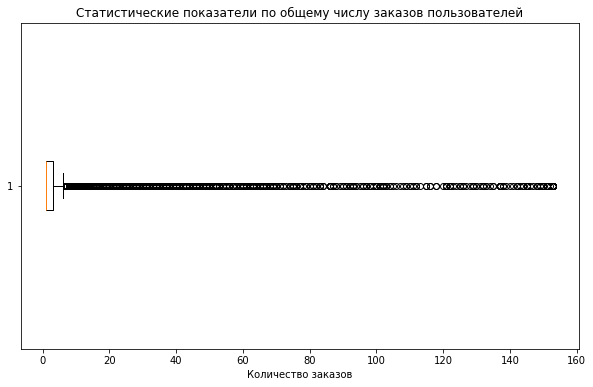

In [65]:
plt.figure(figsize=(10, 6))
plt.boxplot(users_profiles['order_count'], vert=False)
plt.title('Статистические показатели по общему числу заказов пользователей')
plt.xlabel('Количество заказов')
plt.show()

В этом столбце присутствуют выбросы, причём есть пользователь, совершивший более 3000 заказов. Из-за этого среднее значение более, чем в семь раза больше медианы. Отфильтруем данные по 99-му процентилю.

In [66]:
percentile_99 = users_profiles['order_count'].quantile(0.99)
users_profiles['order_count'] = users_profiles['order_count'][users_profiles['order_count']<=percentile_99]

#Изучим статистику отфильтрованного столбца:

users_profiles['order_count'].describe()

count    21719.000000
mean         3.804227
std          7.079767
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max         68.000000
Name: order_count, dtype: float64

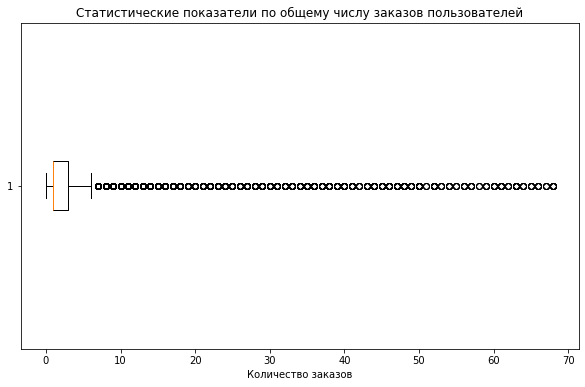

In [67]:
users_profiles['order_count'] = users_profiles['order_count'].fillna(0)
plt.figure(figsize=(10, 6))
plt.boxplot(users_profiles['order_count'], vert=False)
plt.title('Статистические показатели по общему числу заказов пользователей')
plt.xlabel('Количество заказов')
plt.show()

Итак, теперь мы имеем столбец с более реалистичными данными о количестве заказов пользователей за пять месяцев.

In [68]:
users_profiles['avg_tickets_count'].describe()

count    21933.000000
mean         2.757489
std          0.960626
min          1.000000
25%          2.000000
50%          2.833333
75%          3.071429
max         12.000000
Name: avg_tickets_count, dtype: float64

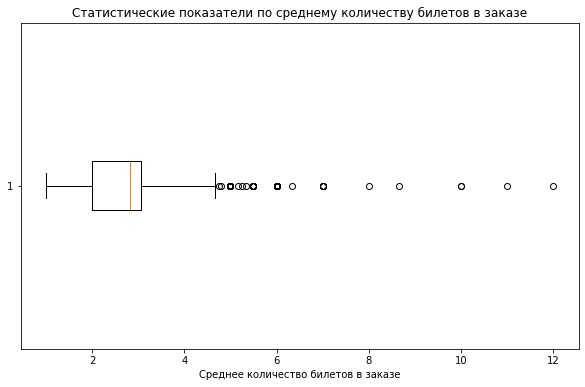

In [69]:
plt.figure(figsize=(10, 6))
plt.boxplot(users_profiles['avg_tickets_count'], vert=False)
plt.title('Статистические показатели по среднему количеству билетов в заказе')
plt.xlabel('Среднее количество билетов в заказе')
plt.show()

В данном столбце тоже присутствуют выбросы, но они практически не влияют на разницу между средним и медианным показателями. Оставим всё как есть.

In [70]:
users_profiles['avg_intervals'].describe()

count                         10808
mean     28 days 09:36:11.879175516
std      27 days 09:15:30.419238905
min                 0 days 00:01:21
25%          9 days 06:05:43.500000
50%      19 days 19:58:48.714285714
75%         37 days 10:00:49.625000
max               148 days 05:27:58
Name: avg_intervals, dtype: object

In [71]:
#Для удобства визуализации преобразуем данные столбца в целочисленный формат:
users_profiles['avg_intervals_days']= users_profiles['avg_intervals'].dt.total_seconds()/86400
users_profiles['avg_intervals_days'].describe()

count    10808.000000
mean        28.400137
std         27.385769
min          0.000937
25%          9.253976
50%         19.832508
75%         37.417241
max        148.227755
Name: avg_intervals_days, dtype: float64

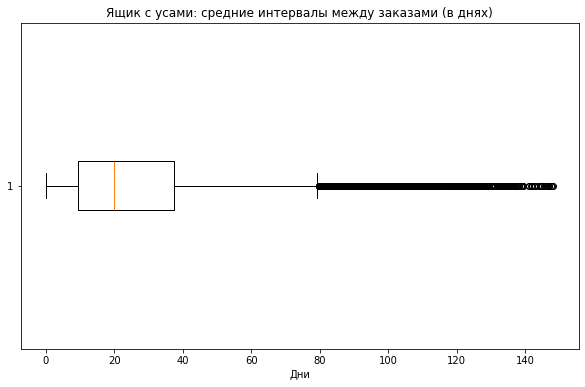

In [72]:
data = users_profiles['avg_intervals_days'].dropna()
plt.figure(figsize=(10, 6))
plt.boxplot(data, vert=False)
plt.title('Ящик с усами: средние интервалы между заказами (в днях)')
plt.xlabel('Дни')
plt.show()

В столбце присутствуют довольно большие интервалы. Тем не менее, учтём их при анализе. К тому же они несущественно влияют на разницу между средним и медианным показателями.

Итак, был создан датафрейм с профилями пользователей, содержащий следующую информацию:
- даты первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (по полю `event_type_main`);
- общее количество заказов;
- среднюю выручку с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

Кроме того, были изучены статистические показатели средней выручки, среднего количества билетов в заказе и среднего времени между заказами по пользователям. Были отфильтрованы по 99-му процентилю данные о количестве заказов.

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [73]:
#Начнём с сегментации по типу первого мероприятия:

users_profiles.groupby('first_event_type')['user_id'].count().sort_values(ascending=False)

first_event_type
концерты    9705
другое      5492
театр       4299
стендап     1116
спорт        808
выставки     418
ёлки          95
Name: user_id, dtype: int64

In [74]:
#Теперь выведем долю каждого сегмента:

segment_counts = users_profiles.groupby('first_event_type')['user_id'].count().sort_values(ascending=False)
(segment_counts/segment_counts.sum()).sort_values(ascending=False)

first_event_type
концерты    0.442484
другое      0.250399
театр       0.196006
стендап     0.050882
спорт       0.036839
выставки    0.019058
ёлки        0.004331
Name: user_id, dtype: float64

Почти половину первых мероприятий пользователей составляют концерты. Четверть - мероприятия неопределённого типа. Почти 20% приходится на театр. Доли остальных сегментов значительно уступают первым трём местам.

In [75]:
#Теперь произведём аналогичные действия с сегментами по устройствам, с которых был сделан первый заказ:

users_profiles.groupby('first_order_device')['user_id'].count().sort_values(ascending=False)

first_order_device
mobile     18133
desktop     3800
Name: user_id, dtype: int64

In [76]:
segment_counts = users_profiles.groupby('first_order_device')['user_id'].count().sort_values(ascending=False)
(segment_counts/segment_counts.sum()).sort_values(ascending=False)

first_order_device
mobile     0.826745
desktop    0.173255
Name: user_id, dtype: float64

Почти 83% первых заказов были сделаны с мобильных устройств.

In [77]:
users_profiles.groupby('first_order_region')['user_id'].count().sort_values(ascending=False)

first_order_region
Каменевский регион          7214
Североярская область        3791
Широковская область         1240
Озернинский край             682
Малиновоярский округ         534
                            ... 
Залесский край                 2
Тихогорская область            2
Верхозёрский край              1
Сосноводолинская область       1
Яснопольский округ             1
Name: user_id, Length: 81, dtype: int64

In [78]:
segment_counts = users_profiles.groupby('first_order_region')['user_id'].count().sort_values(ascending=False)
(segment_counts/segment_counts.sum()).sort_values(ascending=False)

first_order_region
Каменевский регион          0.328911
Североярская область        0.172845
Широковская область         0.056536
Озернинский край            0.031095
Малиновоярский округ        0.024347
                              ...   
Залесский край              0.000091
Тихогорская область         0.000091
Верхозёрский край           0.000046
Сосноводолинская область    0.000046
Яснопольский округ          0.000046
Name: user_id, Length: 81, dtype: float64

Доли Каменевского региона (почти 33%) и Североярской области (более 17%) значительно превосходят доли остальных регионов. 

In [79]:
users_profiles.groupby('first_order_service')['user_id'].count().sort_values(ascending=False)

first_order_service
Билеты без проблем        5226
Мой билет                 3027
Лови билет!               2841
Билеты в руки             2595
Облачко                   2196
Весь в билетах            1307
Лучшие билеты             1193
Прачечная                  590
Край билетов               461
Дом культуры               355
Яблоко                     318
Тебе билет!                312
Городской дом культуры     223
За билетом!                212
Мир касс                   206
Show_ticket                174
Быстробилет                162
Выступления.ру              99
Восьмёрка                   87
Быстрый кассир              61
Росбилет                    50
Crazy ticket!               48
Реестр                      38
Радио ticket                36
Телебилет                   28
Цвет и билет                23
Шоу начинается!             20
КарандашРУ                  16
Кино билет                   9
Вперёд!                      7
Билет по телефону            6
Тех билет          

In [80]:
segment_counts = users_profiles.groupby('first_order_service')['user_id'].count().sort_values(ascending=False)
(segment_counts/segment_counts.sum()).sort_values(ascending=False)

first_order_service
Билеты без проблем        0.238271
Мой билет                 0.138011
Лови билет!               0.129531
Билеты в руки             0.118315
Облачко                   0.100123
Весь в билетах            0.059591
Лучшие билеты             0.054393
Прачечная                 0.026900
Край билетов              0.021019
Дом культуры              0.016186
Яблоко                    0.014499
Тебе билет!               0.014225
Городской дом культуры    0.010167
За билетом!               0.009666
Мир касс                  0.009392
Show_ticket               0.007933
Быстробилет               0.007386
Выступления.ру            0.004514
Восьмёрка                 0.003967
Быстрый кассир            0.002781
Росбилет                  0.002280
Crazy ticket!             0.002188
Реестр                    0.001733
Радио ticket              0.001641
Телебилет                 0.001277
Цвет и билет              0.001049
Шоу начинается!           0.000912
КарандашРУ                0.000729


Более 70% первых заказов пришлись на сервисы "Билеты без проблем", "Мой билет", "Лови билет!", "Билеты в руки" и "Облачко".

По итогам анализа сегментов можно сделать следующие выводы:
- самым популярным видом первых мероприятий пользователей с большим отрывом являются концерты;
- с мобильных устройств более, чем в четыре раза чаще делают первые заказы, чем с компьютеров;
- на два региона приходится почти 50% первых заказов;
- более 70% первых заказов сделаны с помощью сервисов "Билеты без проблем", "Мой билет", "Лови билет!", "Билеты в руки" и "Облачко".

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


In [81]:
#Начнём вновь с типов мероприятий:


users_profiles.query("order_count_characteristics == 'is_two' or order_count_characteristics == 'is_five'").groupby('first_event_type')['user_id'].count().sort_values(ascending=False)

first_event_type
концерты    4865
другое      2693
театр       2141
стендап      549
спорт        323
выставки     205
ёлки          32
Name: user_id, dtype: int64

In [82]:
#Теперь выведем долю таких пользователей от общего количества пользователей по сегментам:

(users_profiles.query("order_count_characteristics == 'is_two' or order_count_characteristics == 'is_five'").groupby('first_event_type')['user_id'].count()/users_profiles.groupby('first_event_type')['user_id'].count()).sort_values(ascending=False)

first_event_type
концерты    0.501288
театр       0.498023
стендап     0.491935
выставки    0.490431
другое      0.490350
спорт       0.399752
ёлки        0.336842
Name: user_id, dtype: float64

В процентном выражении самая большая доля возвращающихся пользователей среди тех, кто впервые посетил выставку. Практически идентичная доля вернувшихся пользователей среди тех, кто впервые посетил театр. При этом стоит учитывать, что в абсолютных числах количество посетителей выставок в десять раз меньше количества тех, кто в качестве первого мероприятия выбрал спектакль.

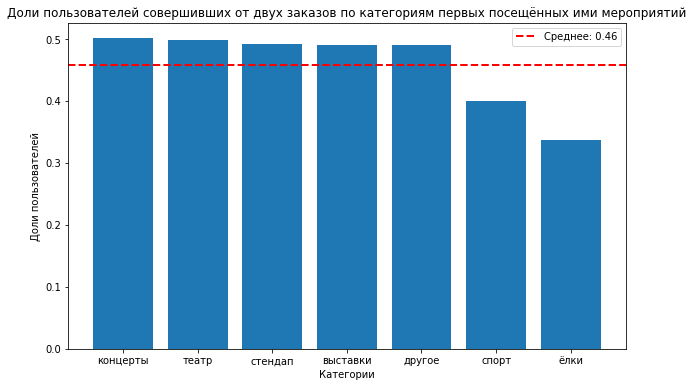

In [83]:
#Теперь визуализируем это в столбчатой диаграмме:

returning_users_by_event_types = (users_profiles.query("order_count_characteristics == 'is_two' or order_count_characteristics == 'is_five'").groupby('first_event_type')['user_id'].count()/users_profiles.groupby('first_event_type')['user_id'].count()).sort_values(ascending=False).reset_index()
returning_users_by_event_types.columns = ['first_event_type', 'count_users']
mean_value = returning_users_by_event_types['count_users'].mean()
plt.figure(figsize=(10, 6))
plt.bar(returning_users_by_event_types['first_event_type'], returning_users_by_event_types['count_users'])
plt.axhline(y=mean_value, color='red', linestyle='--', linewidth=2, label=f'Среднее: {mean_value:.2f}')
plt.title('Доли пользователей совершивших от двух заказов по категориям первых посещённых ими мероприятий')
plt.xlabel('Категории')
plt.ylabel('Доли пользователей')
plt.legend()
plt.show()

Итак, в среднем, 46% пользователей каждого сегмента совершают более двух заказов. Показатели ниже среднего у категорий  `спорт`и `ёлки`.

In [84]:
#Теперь произведём те же операции с другими признаками:

users_profiles.query("order_count_characteristics == 'is_two' or order_count_characteristics == 'is_five'").groupby('first_order_device')['user_id'].count().sort_values(ascending=False)

first_order_device
mobile     8877
desktop    1931
Name: user_id, dtype: int64

Очевидно, что пользователей, сделавших первый заказ с мобильного устройства, возвращается больше, потому что их, в целом, в несколько раз больше.

In [85]:
(users_profiles.query("order_count_characteristics == 'is_two' or order_count_characteristics == 'is_five'").groupby('first_order_device')['user_id'].count()/users_profiles.groupby('first_order_device')['user_id'].count()).sort_values(ascending=False)

first_order_device
desktop    0.508158
mobile     0.489549
Name: user_id, dtype: float64

А вот в процентном выражении доли возвращающихся пользователей по этим сегментам практически идентичны, причём доля возвращающихся пользователей среди тех, кто совершил первый заказ с компьютера, даже чуть больше.

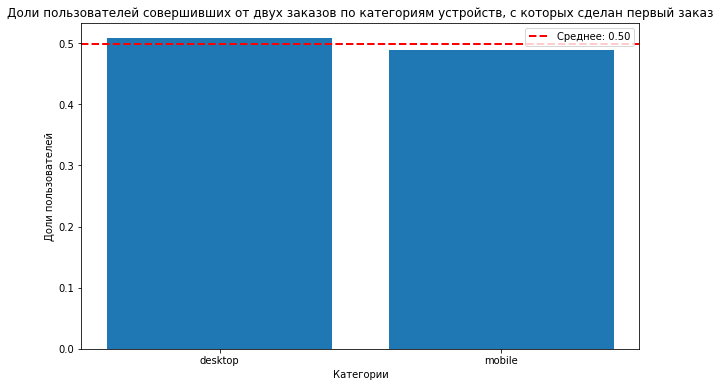

In [86]:
returning_users_by_device_types = (users_profiles.query("order_count_characteristics == 'is_two' or order_count_characteristics == 'is_five'").groupby('first_order_device')['user_id'].count()/users_profiles.groupby('first_order_device')['user_id'].count()).sort_values(ascending=False).reset_index()
returning_users_by_device_types.columns = ['first_order_device', 'count_users']
mean_value = returning_users_by_device_types['count_users'].mean()
plt.figure(figsize=(10, 6))
plt.bar(returning_users_by_device_types['first_order_device'], returning_users_by_device_types['count_users'])
plt.axhline(y=mean_value, color='red', linestyle='--', linewidth=2, label=f'Среднее: {mean_value:.2f}')
plt.title('Доли пользователей совершивших от двух заказов по категориям устройств, с которых сделан первый заказ')
plt.xlabel('Категории')
plt.ylabel('Доли пользователей')
plt.legend()
plt.show()

In [87]:
users_profiles.query("order_count_characteristics == 'is_two' or order_count_characteristics == 'is_five'").groupby('first_order_region')['user_id'].count().sort_values(ascending=False).head(10)

first_order_region
Каменевский регион      3709
Североярская область    1997
Широковская область      625
Шанырский регион         281
Озернинский край         270
Травяная область         259
Светополянский округ     240
Малиновоярский округ     228
Речиновская область      222
Яблоневская область      193
Name: user_id, dtype: int64

In [88]:
returning_users_by_regions = (
    users_profiles
    .query("order_count_characteristics == 'is_two' or order_count_characteristics == 'is_five'")
    .groupby('first_order_region')['user_id']
    .count()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
returning_users_by_regions.columns = ['first_order_region', 'returning_users']
target_regions = returning_users_by_regions['first_order_region'].tolist()

count_users_by_regions = (
    users_profiles[users_profiles['first_order_region'].isin(target_regions)]
    .groupby('first_order_region')['user_id']
    .count()
    .reset_index()
)
count_users_by_regions.columns = ['first_order_region', 'count_users']

users_by_regions = pd.merge(returning_users_by_regions, count_users_by_regions, on='first_order_region')
users_by_regions = users_by_regions.sort_values(by='first_order_region')
users_by_regions['returning_users_share'] = users_by_regions['returning_users'] / users_by_regions['count_users']
users_by_regions = users_by_regions.sort_values(by='returning_users_share', ascending=False)
print(users_by_regions[['first_order_region', 'returning_users_share']])

     first_order_region  returning_users_share
3      Шанырский регион               0.557540
1  Североярская область               0.526774
5      Травяная область               0.522177
0    Каменевский регион               0.514139
6  Светополянский округ               0.513919
2   Широковская область               0.504032
8   Речиновская область               0.503401
9   Яблоневская область               0.460621
7  Малиновоярский округ               0.426966
4      Озернинский край               0.395894


Итак, в первой семёрке регионов (около 9% от выборки) по количеству возвращающихся пользователей их доля относительно всех пользователей примерно равная. Теперь визуализируем данные для большей наглядности.

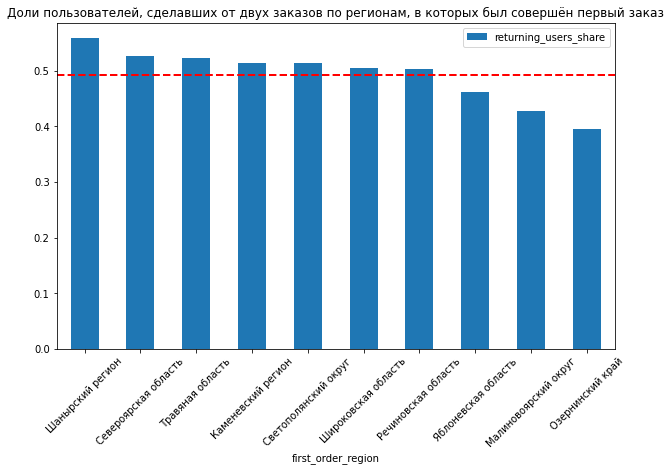

In [89]:
mean_value = users_by_regions['returning_users_share'].mean()

users_by_regions.plot.bar(title='Доли пользователей, сделавших от двух заказов по регионам, в которых был совершён первый заказ',
                                   legend=True,
                                   x='first_order_region',
                                   y='returning_users_share',
                                   rot=45,
                                   figsize=(10, 6))
plt.axhline(y=mean_value, color='red', linestyle='--', linewidth=2, label=f'Среднее: {mean_value:.2f}')
plt.show()

В семи из десяти регионов доля пользователей, сделавших два и более заказов, превышает среднее значение.

In [90]:
returning_users_by_services = users_profiles.query("order_count_characteristics == 'is_two' or order_count_characteristics == 'is_five'").groupby('first_order_service')['user_id'].count().sort_values(ascending=False).head(10).reset_index()
returning_users_by_services.columns = ['first_order_service', 'returning_users']
target_services = returning_users_by_services['first_order_service']
count_users_by_services = (
    users_profiles[users_profiles['first_order_service'].isin(target_services)]
    .groupby('first_order_service')['user_id']
    .count()
    .reset_index()
)
count_users_by_services.columns = ['first_order_service', 'count_users']
users_by_services = pd.merge(returning_users_by_services, count_users_by_services, on='first_order_service')
users_by_services = users_by_services.sort_values(by='first_order_service')
users_by_services['returning_users_share'] = users_by_services['returning_users']/users_by_services['count_users']
users_by_services = users_by_services.sort_values(by='returning_users_share', ascending=False)
print(users_by_services[['first_order_service', 'returning_users_share']])

  first_order_service  returning_users_share
8        Край билетов               0.540130
9        Дом культуры               0.512676
3       Билеты в руки               0.511368
5      Весь в билетах               0.511094
7           Прачечная               0.503390
0  Билеты без проблем               0.500000
4             Облачко               0.494080
1           Мой билет               0.480344
2         Лови билет!               0.473777
6       Лучшие билеты               0.471081


Во всей первой десятке билетных сервисов (около 29% от выборки) процент пользователей, совершивших в них первый заказ и впоследствии использовавших Яндекс.Афишу, примерно одинаков. Теперь визуализируем эту информацию.

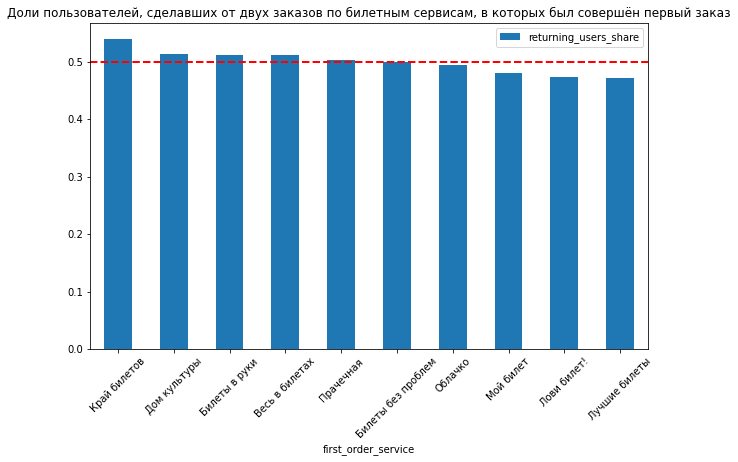

In [91]:
mean_value = users_by_services['returning_users_share'].mean()

users_by_services.plot.bar(title='Доли пользователей, сделавших от двух заказов по билетным сервисам, в которых был совершён первый заказ',
                                   legend=True,
                                   x='first_order_service',
                                   y='returning_users_share',
                                   rot=45,
                                   figsize=(10, 6))
plt.axhline(y=mean_value, color='red', linestyle='--', linewidth=2, label=f'Среднее: {mean_value:.2f}')
plt.show()

Половина первой десятки сервисов находится на уровне среднего показателя (около 48%) количества возвращающихся пользователей и выше.

Итак, исходя из результатов анализа можно сделать следующие выводы:
- сделавшие первый заказ через сервисы "Край билетов", "Дом культуры", "Весь в билетах", "Прачечная" и "Билеты в руки" чаще возвращаются в Яндекс.Афишу;
- сделавшие первый заказ в Шанырском регионе, Североярской области и Тарвяной области чаще более лояльны, чем пользователи из других регионов;
- доля вернувшихся пользователей, сделавших первый заказ с компьютера, чуть больше (51%), в сравнении теми, кто совершил первую покупку с мобильного (49%), но в абсолютных числах ситуация обратная, поскольку пользователей второй категории (8706) в разы больше, чем первой (1940);
- наибольшая доля вернувшихся в Яндекс.Афишу среди тех, кто впервые посещал такие мероприятия, как выставки, спектакли и стендапы.

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

Первая гипотеза верна частично. Действительно, тип мероприятия влияет на вероятность возвращения пользователей в Яндекс.Афишу. При этом пользователи, оформившие первый заказ на концерт, всё-таки возвращаются чаще, чем те, кто оформил первый заказ на спортивное мероприятие. 

Для проверки второй гипотезы изучим корреляцию между количеством пользователей по регионам и долей вернувшихся в Яндекс.Афишу по каждому региону.

In [92]:
users_by_regions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10 entries, 3 to 4
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   first_order_region     10 non-null     object 
 1   returning_users        10 non-null     int64  
 2   count_users            10 non-null     int64  
 3   returning_users_share  10 non-null     float64
dtypes: float64(1), int64(2), object(1)
memory usage: 400.0+ bytes


In [93]:
users_by_regions[['count_users', 'returning_users_share']].corr()

,count_users,returning_users_share
count_users,1.000000,0.248694
returning_users_share,0.248694,1.000000


Корреляция между количеством пользователей в регионе и долей повторных заказов есть, но довольно слабая. Нельзя говорить об этом, как о закономерности.

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


In [94]:
users_profiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21933 entries, 0 to 21932
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype          
---  ------                       --------------  -----          
 0   user_id                      21933 non-null  object         
 1   first_order_dt               21933 non-null  datetime64[ns] 
 2   last_order_dt                21933 non-null  datetime64[ns] 
 3   order_dt                     21933 non-null  datetime64[ns] 
 4   first_order_ts               21933 non-null  datetime64[ns] 
 5   first_order_device           21933 non-null  object         
 6   first_order_region           21933 non-null  object         
 7   first_order_service          21933 non-null  object         
 8   first_event_type             21933 non-null  object         
 9   order_count                  21933 non-null  float64        
 10  avg_revenue                  21817 non-null  float64        
 11  avg_tickets_count           

In [95]:
users_profiles.groupby('order_count_characteristics')['avg_revenue'].mean()

order_count_characteristics
is_five    540.550713
is_two     548.043053
other      543.124067
Name: avg_revenue, dtype: float64

In [96]:
non_loyal_clients_avg_revenue = users_profiles['avg_revenue'][users_profiles['order_count_characteristics']=='other']
loyal_clients_avg_revenue = users_profiles.query("order_count_characteristics == 'is_two' or order_count_characteristics == 'is_five'")['avg_revenue']

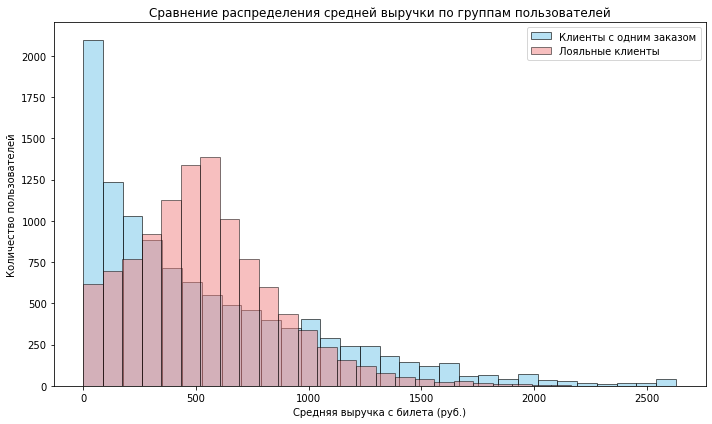

In [97]:
# Настройка фигуры:
plt.figure(figsize=(10, 6))

# Гистограмма для пользователей с 1 заказом
plt.hist(non_loyal_clients_avg_revenue, bins=30, alpha=0.6, color='skyblue', edgecolor='black', label='Клиенты с одним заказом')


# Гистограмма для вернувшихся пользователей
plt.hist(loyal_clients_avg_revenue, bins=30, alpha=0.5, color='lightcoral', edgecolor='black', label='Лояльные клиенты')

plt.title('Сравнение распределения средней выручки по группам пользователей')
plt.xlabel('Средняя выручка с билета (руб.)')
plt.ylabel('Количество пользователей')
plt.legend()



plt.tight_layout()  
plt.show()


Исходя из данной гистограммы можно сделать следующие выводы:
- пользователи, сделавшие один заказ имеют больший разброс выручки с их покупок, в сравнении с лояльными клиентами, выручка от заказов которых сосредоточена, по большей части, в диапазоне от 450 до 600 рублей;
- среди пользователей, сделавших один заказ, много заказов с нулевой выручкой. По всей видимости, они оформляют отказ и больше не пользуются сервисом.

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


In [98]:
loyal_users = users_profiles['avg_revenue'][users_profiles['order_count_characteristics']=='is_two']
ultraloyal_users= users_profiles['avg_revenue'][users_profiles['order_count_characteristics']=='is_five']

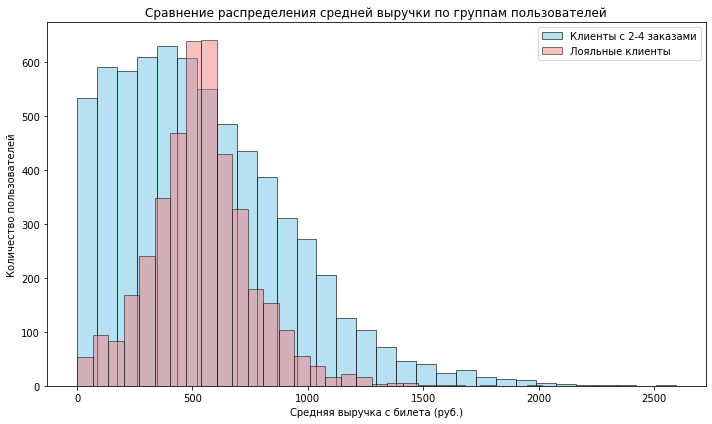

In [99]:
# Настройка фигуры:
plt.figure(figsize=(10, 6))

# Гистограмма для пользователей с 1 заказом
plt.hist(loyal_users, bins=30, alpha=0.6, color='skyblue', edgecolor='black', label='Клиенты с 2-4 заказами')


# Гистограмма для вернувшихся пользователей
plt.hist(ultraloyal_users, bins=30, alpha=0.5, color='lightcoral', edgecolor='black', label='Лояльные клиенты')

plt.title('Сравнение распределения средней выручки по группам пользователей')
plt.xlabel('Средняя выручка с билета (руб.)')
plt.ylabel('Количество пользователей')
plt.legend()



plt.tight_layout()  
plt.show()

Большинство клиентов, сделавших 2-4 заказа, сконцентрированы в диапазоне средней выручки до 600 рублей. Наиболее лояльные клиенты чаще всего делают заказы стоимостью от 450 до 600 рублей. При этом гораздо больше пользователей, сделавших один заказ, делали дорогие покупки, в сравнении с наиболее лояльными пользователями. Из-за большого количества заказов с нулевой выручкой данные о средней выручке с заказов клиентов с одной покупкой тяготеют влево.

In [100]:
#Теперь изучим средние показатели выручки по группам:
users_profiles.groupby('order_count_characteristics')['avg_revenue'].mean()

order_count_characteristics
is_five    540.550713
is_two     548.043053
other      543.124067
Name: avg_revenue, dtype: float64

Сравнение средних значений по группам `is_two` и `is_five` подтверждает данные, представленные на гистограмме. Средняя выручка от клиентов, сделавших 2-4 заказа несколько превышает таковую от самых лояльных клиентов. Скорее всего, это связано с тем, что последние сделали много покупок, в том числе и дешёвых.

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

In [101]:
#Создадим функцию, распределяющую клиентов по категориям, исходя из среднего количества билетов в заказе:

def classification_by_avg_tickets_count(avg_tickets_count):
    if avg_tickets_count<=2:
        return '1-2 билета'
    elif avg_tickets_count>2 and avg_tickets_count<=3:
        return '2-3 билета'
    elif avg_tickets_count>3 and avg_tickets_count<=5:
        return '3-5 билетов'
    else:
        return '5 и более билетов'
    
#Создадим новый столбец:
users_profiles['categories_by_avg_tickets_count'] = users_profiles['avg_tickets_count'].apply(classification_by_avg_tickets_count)
users_profiles['categories_by_avg_tickets_count'].unique()

array(['3-5 билетов', '2-3 билета', '1-2 билета', '5 и более билетов'],
      dtype=object)

In [102]:
#Теперь произведём подсчёт пользователей по категориям:
users_profiles.groupby('categories_by_avg_tickets_count')['user_id'].count().sort_values(ascending=False)

categories_by_avg_tickets_count
2-3 билета           9638
1-2 билета           6766
3-5 билетов          5309
5 и более билетов     220
Name: user_id, dtype: int64

Итак, наибольшее количество пользователей приходится на тех, кто покупает разом 2-3 билета. Люди предпочитают посещать мероприятия небольшими компаниями.

In [103]:
#Теперь изучим доли лояльных пользователей по этим категориям:
(users_profiles.query("order_count_characteristics == 'is_two' or order_count_characteristics == 'is_five'").groupby('categories_by_avg_tickets_count')['user_id'].count()/users_profiles.groupby('categories_by_avg_tickets_count')['user_id'].count()).sort_values(ascending=False)

categories_by_avg_tickets_count
2-3 билета           0.647645
3-5 билетов          0.503673
1-2 билета           0.275791
5 и более билетов    0.118182
Name: user_id, dtype: float64

Самая большая доля лояльных клиентов также приходится на людей, покупающих 2-3 билета (почти 65%). Также почти 50% возвращаются среди тех, кто покупает в среднем 3-5 билетов. Аномальных значений нет. По всей видимости, наиболее лояльные пользователи - небольшие семьи и компании друзей. Реже всего возвращаются пользователи, которые приобрели более пяти билетов. Скорее всего, это определённые организации, устроившие выездные мероприятия для сотрудников или детей (в случае с образовательными организациями).

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [104]:
#Создадим в датафрейме users_profiles столбец с днями недели первых заказов:

users_profiles['first_order_dow'] = users_profiles['first_order_dt'].dt.day_name()
users_profiles['first_order_dow'].unique()

array(['Tuesday', 'Saturday', 'Thursday', 'Sunday', 'Monday', 'Wednesday',
       'Friday'], dtype=object)

In [105]:
#Теперь сгруппируем пользователей по дням недели их первых заказов:

count_users_by_dow = users_profiles.groupby('first_order_dow')['user_id'].count().sort_values(ascending=False).reset_index()
print(count_users_by_dow)

  first_order_dow  user_id
0        Saturday     3461
1          Friday     3274
2         Tuesday     3218
3        Thursday     3130
4       Wednesday     3084
5          Monday     2947
6          Sunday     2819


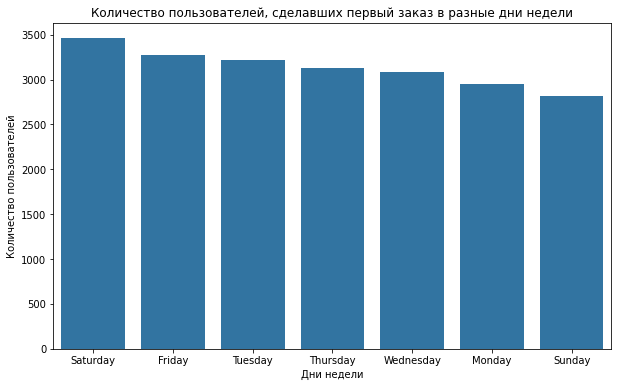

In [106]:
#Визуализируем результат в виде столбчатой диаграммы:

count_users_by_dow.columns = ['Дни недели', 'Количество пользователей']

plt.figure(figsize=(10, 6))
sns.barplot(data=count_users_by_dow, x='Дни недели', y='Количество пользователей')
plt.title('Количество пользователей, сделавших первый заказ в разные дни недели')
plt.show()

Итак, чаще всего первый заказ делают в субботу, а реже всего - в воскресенье.

In [107]:
#Теперь посчитаем долю лояльных пользователей по дням недели их первых заказов:

loyal_users_shares_by_dow = (users_profiles.query("order_count_characteristics == 'is_two' or order_count_characteristics == 'is_five'").groupby('first_order_dow')['user_id'].count()/users_profiles.groupby('first_order_dow')['user_id'].count()).sort_values(ascending=False).reset_index()
loyal_users_shares_by_dow.columns = ['Дни недели', 'Доля лояльных пользователей']
print(loyal_users_shares_by_dow)

  Дни недели  Доля лояльных пользователей
0   Saturday                     0.523837
1     Monday                     0.508653
2    Tuesday                     0.497825
3     Sunday                     0.494147
4  Wednesday                     0.493515
5     Friday                     0.480452
6   Thursday                     0.449201


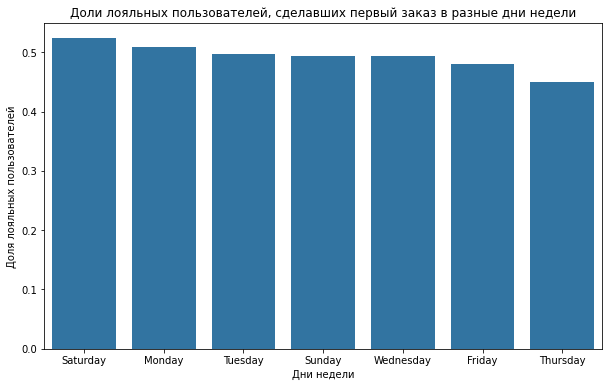

In [108]:
#Теперь визуализируем результаты:

plt.figure(figsize=(10, 6))
sns.barplot(data=loyal_users_shares_by_dow, x='Дни недели', y='Доля лояльных пользователей')
plt.title('Доли лояльных пользователей, сделавших первый заказ в разные дни недели')
plt.show()

Самая большая доля лояльных пользователей приходится на тех, кто сделал первый заказ в субботу. При этом серьёзной разницы по дням недели не наблюдается. Во всех случаях доля лояльных пользователей составляет около 50%. Таким образом, нельзя утверждать, что день недели первого заказа влияет на лояльность клиентов.

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [109]:
users_profiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21933 entries, 0 to 21932
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype          
---  ------                           --------------  -----          
 0   user_id                          21933 non-null  object         
 1   first_order_dt                   21933 non-null  datetime64[ns] 
 2   last_order_dt                    21933 non-null  datetime64[ns] 
 3   order_dt                         21933 non-null  datetime64[ns] 
 4   first_order_ts                   21933 non-null  datetime64[ns] 
 5   first_order_device               21933 non-null  object         
 6   first_order_region               21933 non-null  object         
 7   first_order_service              21933 non-null  object         
 8   first_event_type                 21933 non-null  object         
 9   order_count                      21933 non-null  float64        
 10  avg_revenue                      21817 non-nul

In [110]:
#Создадим столбец с категориями пользователей по количеству заказов:

def classification_by_order_count(order_count):
    if order_count>=2 and order_count<=4:
        return '2-4 заказа'
    elif order_count>4:
        return '5 и более заказов'
    else:
        return '1 заказ'
    
users_profiles['classification_by_order_count'] = users_profiles['order_count'].apply(classification_by_order_count)
users_profiles['classification_by_order_count'].unique()

array(['1 заказ', '2-4 заказа', '5 и более заказов'], dtype=object)

In [111]:
#Изучим средний интервал между заказами по новым категориям пользователей:

users_profiles.groupby('classification_by_order_count')['avg_intervals_days'].mean().sort_values(ascending=False)

classification_by_order_count
2-4 заказа           37.325795
5 и более заказов    14.482352
1 заказ               1.456441
Name: avg_intervals_days, dtype: float64

Пользователи, сделавшие 2-4 заказа, делают покупки, в среднем, гораздо реже, чем более лояльные пользователи.

In [112]:
#Теперь изучим корреляцию между средним интервалом между заказами и вероятностью повторного заказа:

users_profiles[['avg_intervals_days', 'order_count']].corr()

,avg_intervals_days,order_count
avg_intervals_days,1.00000,-0.32637
order_count,-0.32637,1.00000


Между количеством заказов и интервалами между ними имеется небольшая отрицательная корреляция. Чем меньше заказов - тем больше промежутки между ними. 

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [113]:
users_profiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21933 entries, 0 to 21932
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype          
---  ------                           --------------  -----          
 0   user_id                          21933 non-null  object         
 1   first_order_dt                   21933 non-null  datetime64[ns] 
 2   last_order_dt                    21933 non-null  datetime64[ns] 
 3   order_dt                         21933 non-null  datetime64[ns] 
 4   first_order_ts                   21933 non-null  datetime64[ns] 
 5   first_order_device               21933 non-null  object         
 6   first_order_region               21933 non-null  object         
 7   first_order_service              21933 non-null  object         
 8   first_event_type                 21933 non-null  object         
 9   order_count                      21933 non-null  float64        
 10  avg_revenue                      21817 non-nul

In [114]:
df_without_columns = users_profiles.drop(columns=['avg_intervals', 'user_id', 'first_order_ts'])

def convert_ts(row):
    return (row - pd.Timestamp('2024-07-01')).days
    
df_without_columns['days_since_1_7_24_first_order'] = df_without_columns['first_order_dt'].apply(convert_ts)
df_without_columns['days_since_1_7_24_last_order'] = df_without_columns['last_order_dt'].apply(convert_ts)
df_without_columns = df_without_columns.drop(columns=['first_order_dt', 'last_order_dt', 'order_dt', 'classification_by_order_count'])
phik_mat = df_without_columns.phik_matrix(interval_cols=['avg_intervals_days', 'avg_revenue', 'avg_tickets_count', 'days_since_1_7_24_first_order', 'days_since_1_7_24_last_order'])

correlation_with_target = phik_mat['order_count_characteristics'].sort_values(ascending=False)
print(correlation_with_target)

order_count                        1.000000
order_count_characteristics        1.000000
avg_intervals_days                 0.624665
days_since_1_7_24_first_order      0.567405
avg_tickets_count                  0.546831
days_since_1_7_24_last_order       0.542566
avg_revenue                        0.404519
categories_by_avg_tickets_count    0.272878
first_order_region                 0.149560
first_order_service                0.099442
first_order_dow                    0.069591
first_event_type                   0.053230
first_order_device                 0.014084
Name: order_count_characteristics, dtype: float64


Cледует отметить, что с остальными признаками количество заказов показывает достаточно весомую корреляцию. Близки к нулю показатели корреляции количества заказов с устройством, с которого сделан первый заказ, типом первого посещённого мероприятия, сервисом, с помощью которого был сделан первый заказ, и днём недели. Проверим разброс данных о количестве заказов в зависимости от данных категорий.

<Axes: title={'center': 'Разброс данных о количестве заказов пользователей в зависимости от типа первого посещённого ими мероприятия'}, xlabel='first_event_type', ylabel='order_count'>

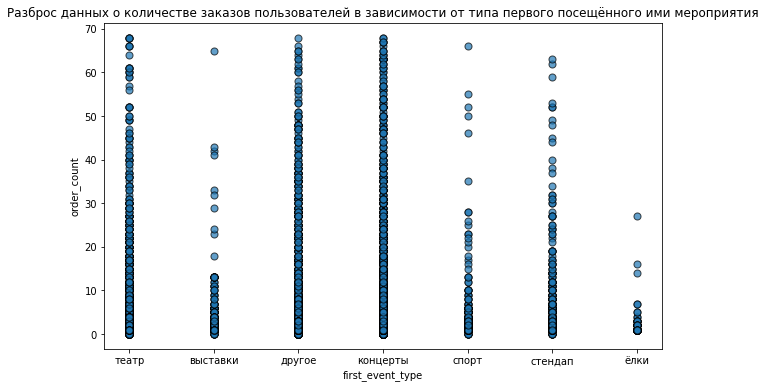

In [115]:
df_without_columns.plot(kind='scatter', x='first_event_type', y='order_count', alpha=0.7, edgecolor='black', s=50, figsize=(10, 6), title='Разброс данных о количестве заказов пользователей в зависимости от типа первого посещённого ими мероприятия')

Судя по графику, пользователи, выбравшие в качестве первого мероприятия театр, концерты и неопределённую категорию, имеют примерно равное распределение по количеству заказов. Те, кто в первый раз посетили другие мероприятия, в среднем, делают меньше заказов. Таким образом, пусть небольшая, но зависимость лояльности от категории первого мероприятия действительно есть.

<Axes: title={'center': 'Разброс данных о количестве заказов пользователей в зависимости от дня недели, в который сделан первый заказ'}, xlabel='first_order_dow', ylabel='order_count'>

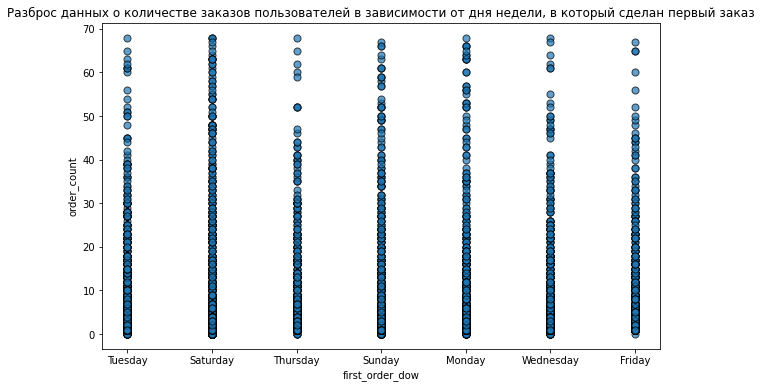

In [116]:
#Теперь изучим разброс данных о количестве заказов в зависимости от дня недели, в который сделан первый заказ:

df_without_columns.plot(kind='scatter', 
                        x='first_order_dow', 
                        y='order_count', 
                        alpha=0.7, 
                        edgecolor='black', 
                        s=50, 
                        figsize=(10, 6), 
                        title='Разброс данных о количестве заказов пользователей в зависимости от дня недели, в который сделан первый заказ')

Данный график показывает примерно равное распределение лояльных пользователей по дням недели. Чуть больше концентрация пользователей с большим количеством заказов (свыше 60) приходится на субботу, воскресенье и понедельник.

<Axes: title={'center': 'Разброс данных о количестве заказов пользователей в зависимости от устройства, с которого сделан первый заказ'}, xlabel='first_order_device', ylabel='order_count'>

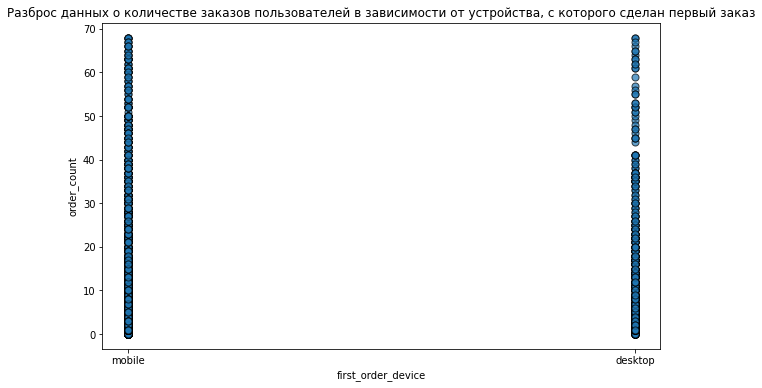

In [117]:
#Теперь изучим разброс данных о количестве заказов в зависимости от устройства, с которого сделан первый заказ:

df_without_columns.plot(kind='scatter', 
                        x='first_order_device', 
                        y='order_count', 
                        alpha=0.7, 
                        edgecolor='black', 
                        s=50, 
                        figsize=(10, 6), 
                        title='Разброс данных о количестве заказов пользователей в зависимости от устройства, с которого сделан первый заказ')

Более лояльные клиенты сделали свой первый заказ с мобильного устройства

<Axes: title={'center': 'Разброс данных о количестве заказов пользователей в зависимости от сервиса, с помощью которого был сделан первый заказ'}, xlabel='first_order_service', ylabel='order_count'>

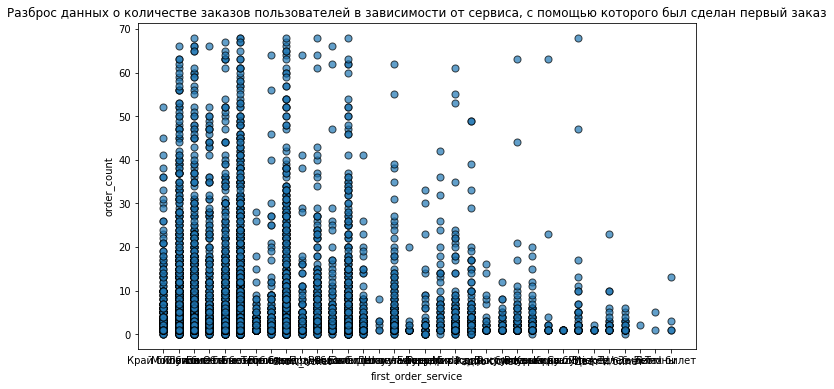

In [118]:
#Наконец, изучим разброс данных по количеству заказов в зависимости от сервиса, с помощью которого был сделан первый заказ:

df_without_columns.plot(kind='scatter', 
                        x='first_order_service', 
                        y='order_count', 
                        alpha=0.7, 
                        edgecolor='black', 
                        s=50, 
                        figsize=(10, 6), 
                        title='Разброс данных о количестве заказов пользователей в зависимости от сервиса, с помощью которого был сделан первый заказ')

Имеют место несколько сервисов, которыми воспользовалось большинство лояльных пользователей. Остальными впервые воспользовались пользователи, сделавшие минимальное количество заказов.

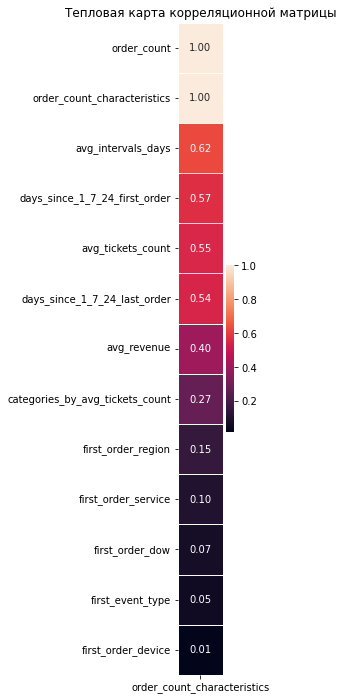

In [119]:
#Теперь визуализируем корреляционную матрицу в виде тепловой карты:
correlation_with_target = pd.DataFrame(correlation_with_target)

plt.figure(figsize=(1, 12))
sns.heatmap(data=correlation_with_target, annot=True, fmt='.2f', linewidths=0.5)
plt.title('Тепловая карта корреляционной матрицы')
plt.show()

Наибольшую связь с количеством заказов показывают средние интервалы между заказами, даты первого заказа и среднее количество билетов в заказе.

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

В ходе работы над проектом была изучена информация о 21933 пользователях. Причём при составлении выборки данные были отфильтрованы по 99-му процентилю столбцов о стоимости заказа, поскольку там были существенные выбросы, о количестве заказов пользователей, поскольку там имели место нереалистичные значения, свидетельствовавшие о дублировании данных о заказах. Кроме того, для работы с данными не очень подходил столбец, в котором были собраны данные о стоимости заказов и в рублях, и в тенге. С помощью датафрейма, в котором собраны сведения о курсе тенге к рублю за 2024 год, был создан столбец, в котором указана стоимость заказов только в рублях.

Большинство пользователей из выборки сделали один заказ (11287), 6533 сделали от двух до четырёх заказов, и 4113 пользователей - более пяти. Следует выделить категорию лояльных пользователей, которые в качестве первого мероприятия посетили концерт. Их наибольшее количество - 4683. При этом доля лояльных клиентов наибольшая среди тех, кто в качестве первого мероприятия посетил театр. Впрочем, доли лояльных среди тех, кто посетил впервые выставки, стендапы, неопределённую категорию мероприятий и концерты, примерно схожие - около 50%. Заметно больше людей совершает первый заказ с мобильных устройств (18150) в сравнении с компьютерами (3783). Также следует отметить, что около половины пользователей из выборки приходится на три региона. При этом важно отметить, что многочисленность клиентов в регионе слабо коррелирует с их лояльностью. 

Как показал корреляционный анализ, в наибольшей степени с лояльностью клиентов взаимосвязаны интервалы между заказами. Корреляция средней выручки с клиента с количеством заказов составляет 0,41. Корреляция со средним количеством билетов в заказе составляет 0,55. При этом дни недели, в которые был сделан первый заказ, практически не влияют на лояльность пользователей. Но всё же отметим, что самое большое количество лояльных клиентов сделали свой первый заказ в субботу.

Исходя из результатов проведённого анализа, можно выделить следующие рекомендации:
- сделать упор на улучшении удобства мобильного приложения, поскольку большинство новых клиентов делают и будут делать заказы с мобильных устройств. Это удобно - можно делать и лёжа, и на ходу;
- сделать акцент на контекстной рекламе, т.к. пользователи, посещавшие разные мероприятия в 50% случаях становятся лояльными. Соответственно стоить работать на разные аудитории, уже делавшие заказы на определённые мероприятия, чтобы они и в дальнейшем их посещали. Кроме того, по мере увеличения количества заказов растут интервалы между ними, а значит нужно активнее работать с наиболее лояльной аудиторией.